Index(['Incident ID', 'Date', 'Time', 'Category', 'Severity', 'Department',
       'Location', 'Description', 'Root Cause', 'Injuries', 'Lost Time Days',
       'Corrective Action', 'Status', 'Closed Date',
       'Severity (Numeric) 1=Near Miss … 5=Critical',
       'Category (Numeric) See legend', 'Department (Numeric) See legend',
       'Location (Numeric) See legend', 'Root Cause (Numeric) See legend',
       'Status (Numeric) See legend', 'Month (1–12)',
       'Day of Week 1=Mon … 7=Sun'],
      dtype='object')

MODEL TRAINED SUCCESSFULLY

MODEL EVALUATION
----------------------
Mean Absolute Error: 3.3703827426112554
R2 Score: 0.5052529810982075

ACTUAL VS PREDICTED:

    Actual  Predicted
83       0   1.136791
53       5   6.085155
70       4  11.033518
45       0  -3.811573
44       0  -3.811573
39       0   1.136791
22       0   1.136791
80       0  -3.811573
10       0   1.136791
0        0  -3.811573


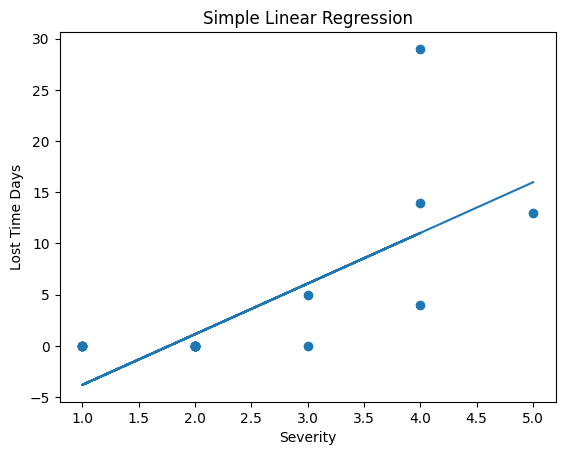

In [ ]:
# -----------------------------------
# SIMPLE LINEAR REGRESSION
# INDUSTRIAL INCIDENT DATASET
# -----------------------------------

# Import Libraries
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

import matplotlib.pyplot as plt


# -----------------------------------
# LOAD DATASET
# -----------------------------------

df = pd.read_excel("industrial_incident_reports (1).xlsx")

# Clean column names
df.columns = df.columns.str.replace('\n', ' ')
df.columns = df.columns.str.strip()

# Display columns
print(df.columns)


# -----------------------------------
# SELECT SINGLE INPUT FEATURE (X)
# -----------------------------------

# Using Severity only

X = df[['Severity (Numeric) 1=Near Miss … 5=Critical']]


# -----------------------------------
# SELECT OUTPUT VARIABLE (Y)
# -----------------------------------

Y = df['Lost Time Days']


# -----------------------------------
# SPLIT DATASET
# -----------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    Y,
    test_size=0.2,
    random_state=42
)


# -----------------------------------
# CREATE MODEL
# -----------------------------------

model = LinearRegression()


# -----------------------------------
# TRAIN MODEL
# -----------------------------------

model.fit(X_train, y_train)

print("\nMODEL TRAINED SUCCESSFULLY")


# -----------------------------------
# MAKE PREDICTIONS
# -----------------------------------

y_pred = model.predict(X_test)


# -----------------------------------
# EVALUATE MODEL
# -----------------------------------

mae = mean_absolute_error(y_test, y_pred)

r2 = r2_score(y_test, y_pred)

print("\nMODEL EVALUATION")
print("----------------------")

print("Mean Absolute Error:", mae)

print("R2 Score:", r2)


# -----------------------------------
# DISPLAY ACTUAL VS PREDICTED
# -----------------------------------

results = pd.DataFrame({
    'Actual': y_test,
    'Predicted': y_pred
})

print("\nACTUAL VS PREDICTED:\n")

print(results.head(10))


# -----------------------------------
# GRAPH
# -----------------------------------

plt.scatter(X_test, y_test)

plt.plot(X_test, y_pred)

plt.xlabel("Severity")

plt.ylabel("Lost Time Days")

plt.title("Simple Linear Regression")

plt.show()


# -----------------------------------
# USER INPUT PREDICTION
# -----------------------------------

severity = float(input("\nEnter Severity (1-5): "))

prediction = model.predict([[severity]])

print("\nPredicted Lost Time Days:")

print(prediction[0])